# Install/import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Import Dataset

In [5]:
import pandas as pd

df = pd.read_excel("/content/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Missing Values

In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [11]:
#Removing CustomerID
df = df.dropna(subset=['CustomerID'])

In [12]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


# Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(5225)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(401604, 8)

# Cancelled Transactions

In [16]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8872)

In [17]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Invalid Quantity

In [18]:
df['Quantity'].describe()

,Quantity
count,392732.000000
mean,13.153718
std,181.588420
min,1.000000
25%,2.000000
50%,6.000000
75%,12.000000
max,80995.000000


In [19]:
df = df[df['Quantity'] > 0]

# Invalid Price

In [20]:
df['UnitPrice'].describe()

,UnitPrice
count,392732.000000
mean,3.125596
std,22.240725
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,8142.750000


In [21]:
df = df[df['UnitPrice'] > 0]

# Create Revenue (Feature Engineering)

In [22]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [23]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


# Date Conversion

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [25]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

# Create Date Features

In [26]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

In [27]:
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

In [28]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,DayOfWeek,MonthYear
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,2010-12


# Final Clean Dataset Check

In [29]:
df.shape

(392692, 14)

In [30]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0
Year,0


In [31]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Day
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532


# RETAIL SALES TRENDS

In [32]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [33]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8887208.894


In [34]:
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [35]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('MonthYear')['Revenue'].sum()

monthly_revenue

,Revenue
MonthYear,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


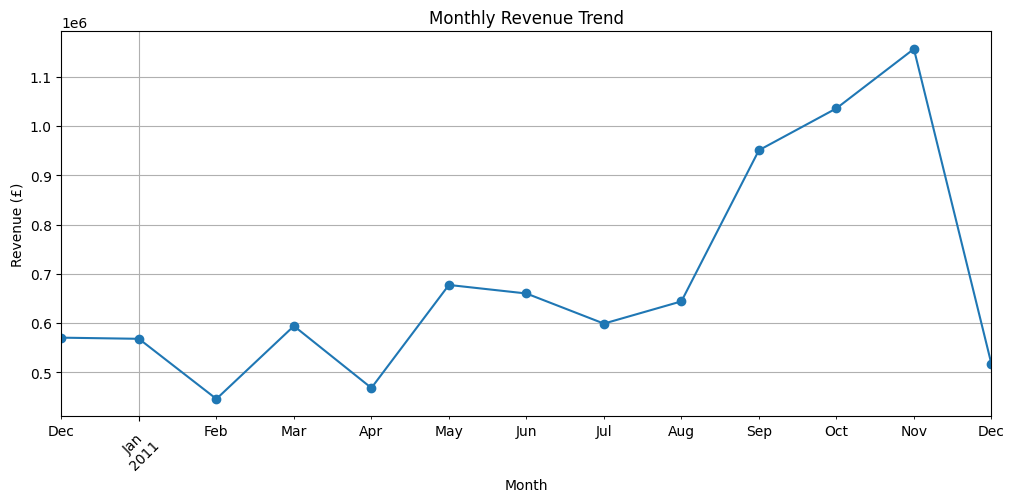

In [36]:
plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line',marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [37]:
monthly_orders = df.groupby('MonthYear')['InvoiceNo'].nunique()

monthly_orders

,InvoiceNo
MonthYear,
2010-12,1400
2011-01,987
2011-02,997
2011-03,1321
2011-04,1149
2011-05,1555
2011-06,1393
2011-07,1331
2011-08,1280


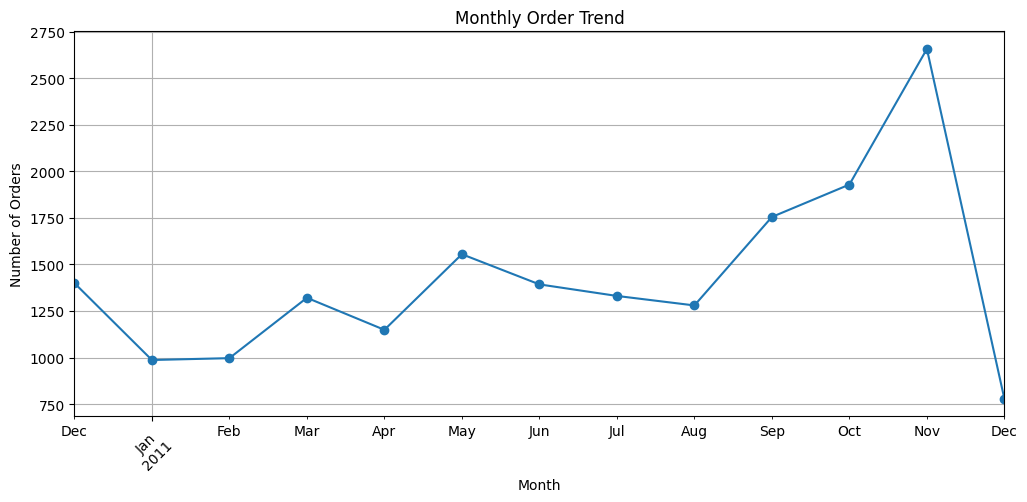

In [38]:
plt.figure(figsize=(12, 5))

monthly_orders.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [39]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


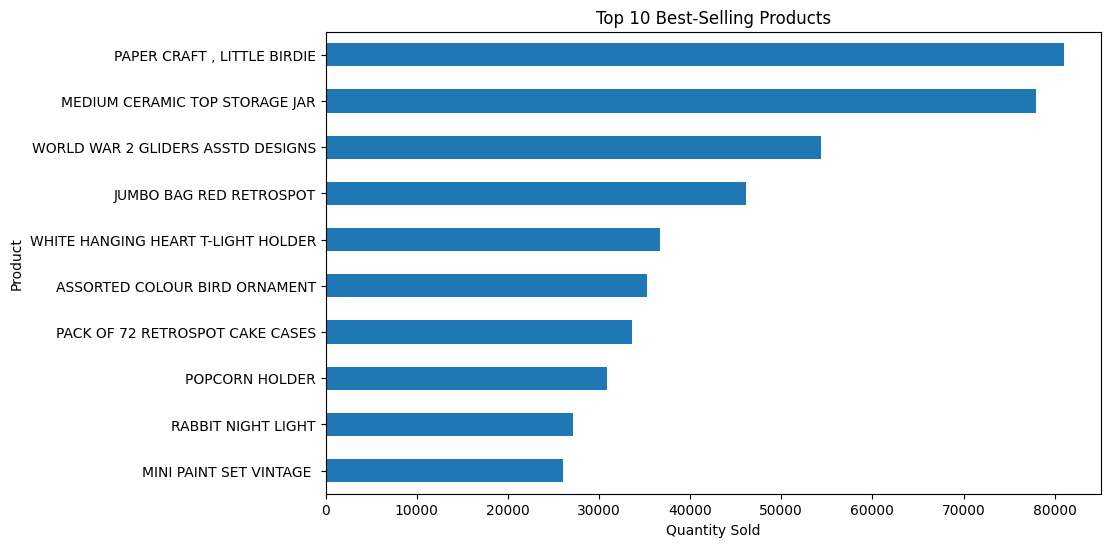

In [40]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.show()

In [41]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


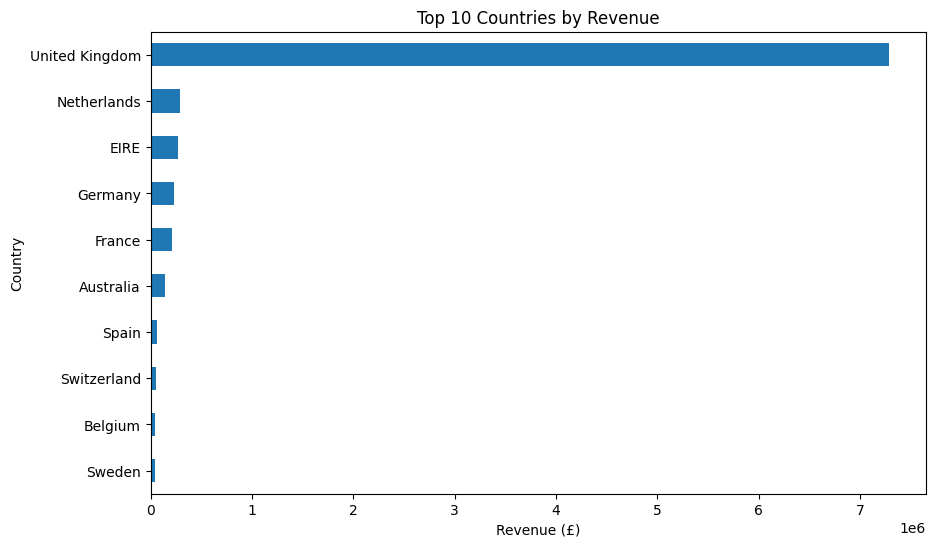

In [42]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.show()

In [43]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

day_sales = (
    df.groupby('DayOfWeek')['Revenue']
    .sum()
)

day_sales

,Revenue
DayOfWeek,
Friday,1483080.811
Monday,1363604.401
Sunday,785490.321
Thursday,1973015.730
Tuesday,1697733.801
Wednesday,1584283.830


In [44]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_sales = day_sales.reindex(day_order)

day_sales

,Revenue
DayOfWeek,
Monday,1363604.401
Tuesday,1697733.801
Wednesday,1584283.830
Thursday,1973015.730
Friday,1483080.811
Saturday,NaN
Sunday,785490.321


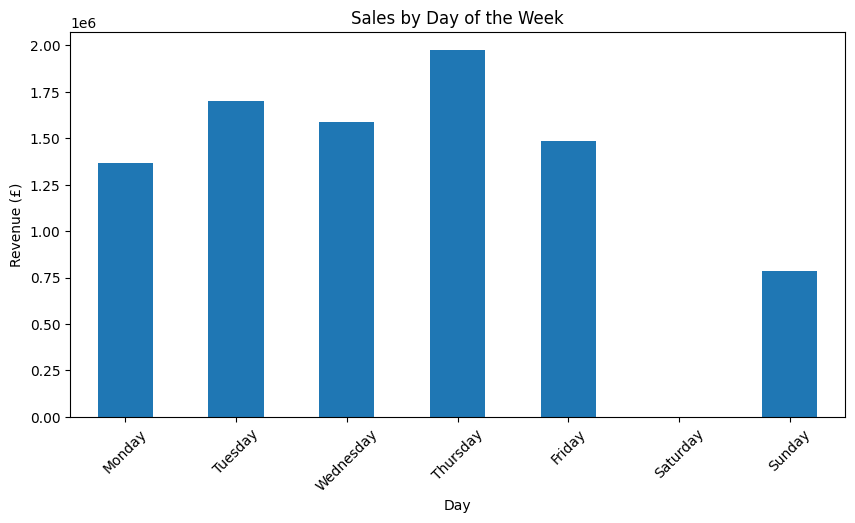

In [45]:
plt.figure(figsize=(10, 5))

day_sales.plot(
    kind='bar'
)

plt.title('Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.show()

In [46]:
top_products_revenue = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


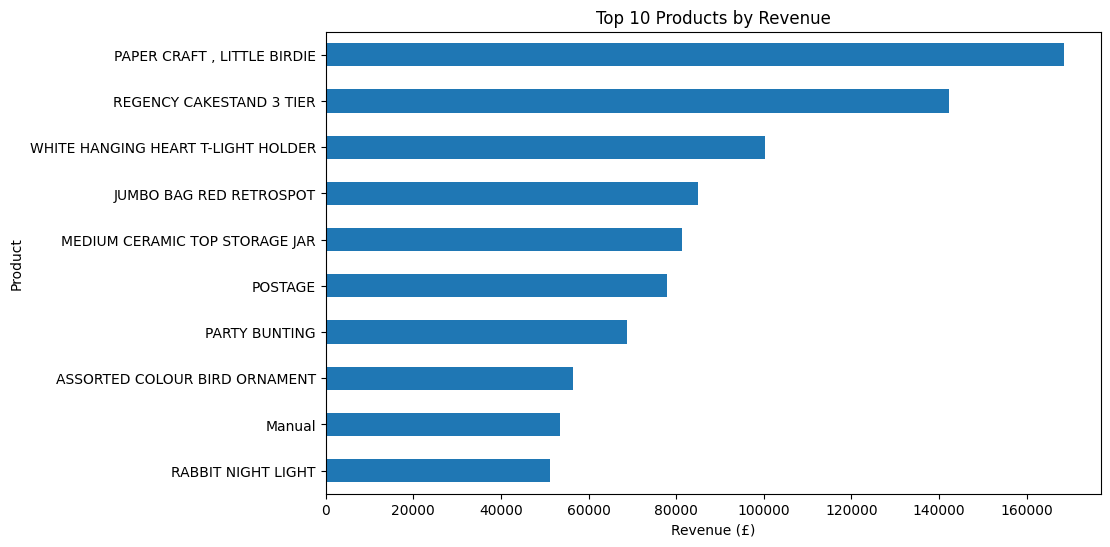

In [47]:
plt.figure(figsize=(10, 6))

top_products_revenue.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.show()

# CUSTOMER SEGMENTATION

In [48]:
customer_data = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'Revenue': 'sum'
})

customer_data.head()

,InvoiceNo,Quantity,Revenue
CustomerID,,,
12346.0,1,74215,77183.60
12347.0,7,2458,4310.00
12348.0,4,2341,1797.24
12349.0,1,631,1757.55
12350.0,1,197,334.40


In [49]:
customer_data.columns = [
    'Number_of_Orders',
    'Total_Quantity',
    'Total_Revenue'
]

customer_data.head()

,Number_of_Orders,Total_Quantity,Total_Revenue
CustomerID,,,
12346.0,1,74215,77183.60
12347.0,7,2458,4310.00
12348.0,4,2341,1797.24
12349.0,1,631,1757.55
12350.0,1,197,334.40


In [50]:
customer_data.describe()

,Number_of_Orders,Total_Quantity,Total_Revenue
count,4338.000000,4338.000000,4338.000000
mean,4.272015,1187.644537,2048.688081
std,7.697998,5043.619654,8985.230220
min,1.000000,1.000000,3.750000
25%,1.000000,159.000000,306.482500
50%,2.000000,378.000000,668.570000
75%,5.000000,989.750000,1660.597500
max,209.000000,196915.000000,280206.020000


In [51]:
customer_data.sort_values(
    'Total_Revenue',
    ascending=False
).head(10)

,Number_of_Orders,Total_Quantity,Total_Revenue
CustomerID,,,
14646.0,73,196915,280206.02
18102.0,60,64124,259657.30
17450.0,46,69973,194390.79
16446.0,2,80997,168472.50
14911.0,201,80240,143711.17
12415.0,21,77374,124914.53
14156.0,55,57768,117210.08
17511.0,31,64549,91062.38
16029.0,63,40108,80850.84


In [52]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [53]:
recency = df.groupby('CustomerID')['InvoiceDate'].max().apply(
    lambda x: (reference_date - x).days
)

recency.head()

,InvoiceDate
CustomerID,
12346.0,326
12347.0,2
12348.0,75
12349.0,19
12350.0,310


In [54]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

frequency.head()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1


In [55]:
monetary = df.groupby('CustomerID')['Revenue'].sum()

monetary.head()

,Revenue
CustomerID,
12346.0,77183.60
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40


In [56]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [57]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


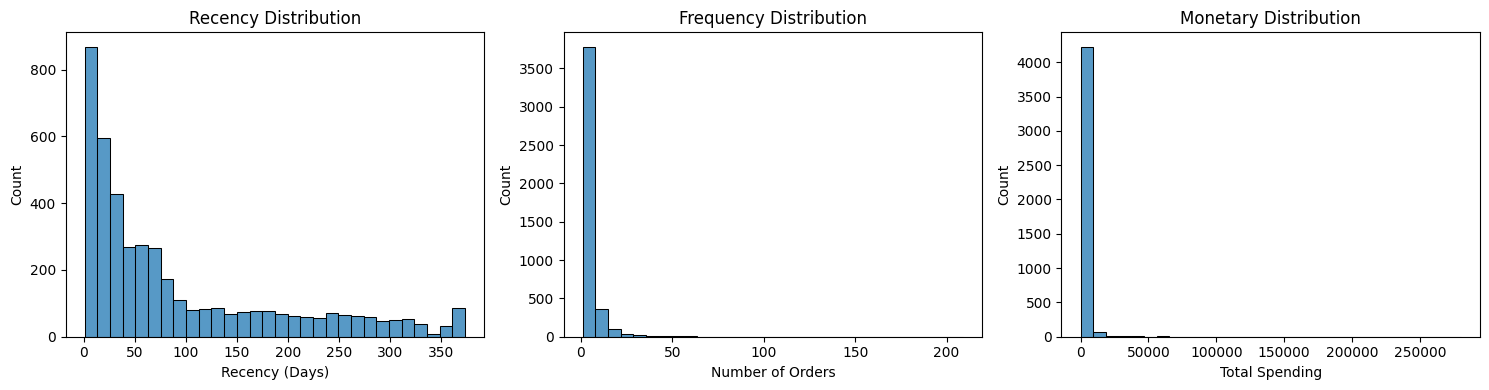

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.xlabel('Recency (Days)')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')
plt.xlabel('Number of Orders')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')
plt.xlabel('Total Spending')

plt.tight_layout()
plt.show()

In [59]:
rfm_log = np.log1p(rfm)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [60]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [62]:
rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

In [63]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

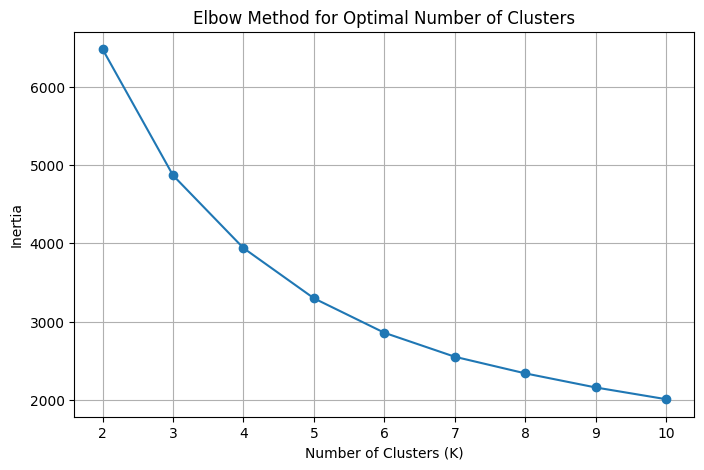

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

plt.show()

In [65]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

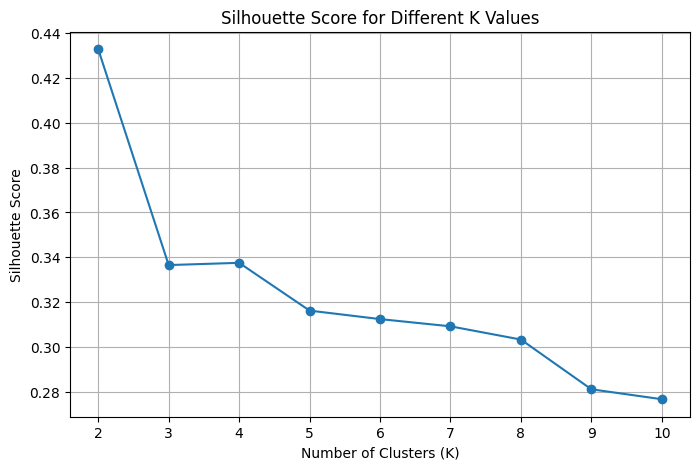

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.show()

In [67]:
optimal_k = 4

In [68]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [69]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


In [70]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

,count
Cluster,
0,713
1,1622
2,837
3,1166


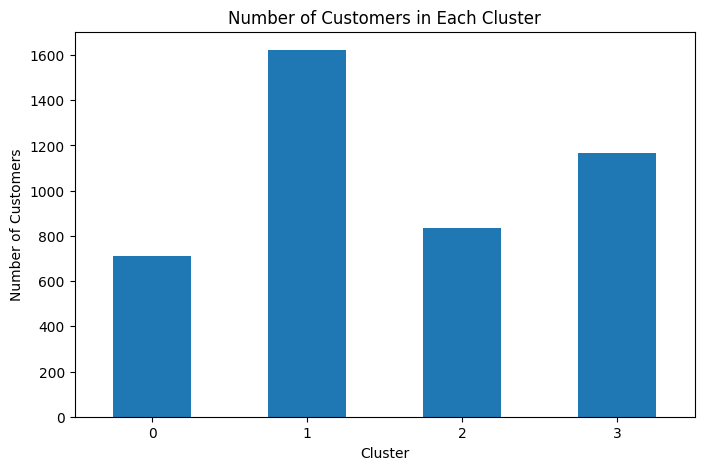

In [71]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [72]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


In [73]:
segment_names = {
    0: 'High-Value Loyal Customers',
    1: 'At-Risk Customers',
    2: 'Regular Customers',
    3: 'Low-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

In [74]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Low-Value Customers
12347.0,2,7,4310.00,0,High-Value Loyal Customers
12348.0,75,4,1797.24,3,Low-Value Customers
12349.0,19,1,1757.55,2,Regular Customers
12350.0,310,1,334.40,1,At-Risk Customers


In [75]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,181.51,1.32,341.00
High-Value Loyal Customers,12.17,13.75,8088.02
Low-Value Customers,71.64,4.08,1801.78
Regular Customers,17.70,2.19,557.32


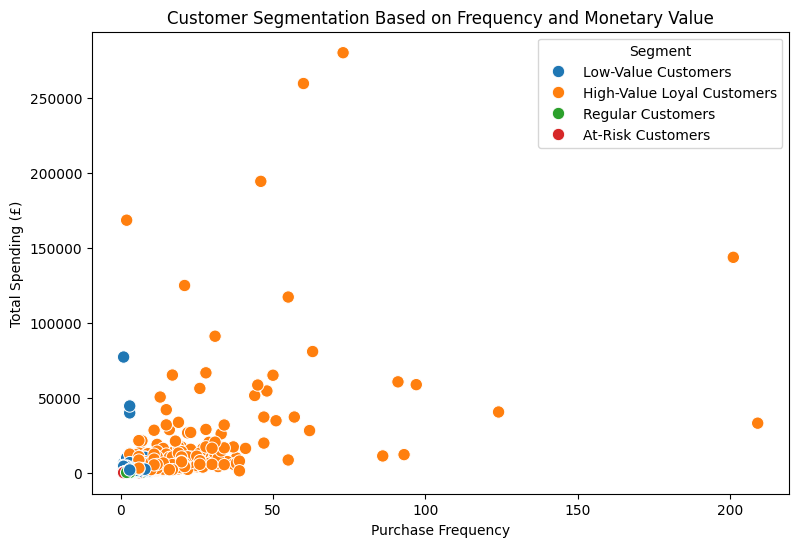

In [76]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    s=80
)

plt.title('Customer Segmentation Based on Frequency and Monetary Value')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending (£)')

plt.show()

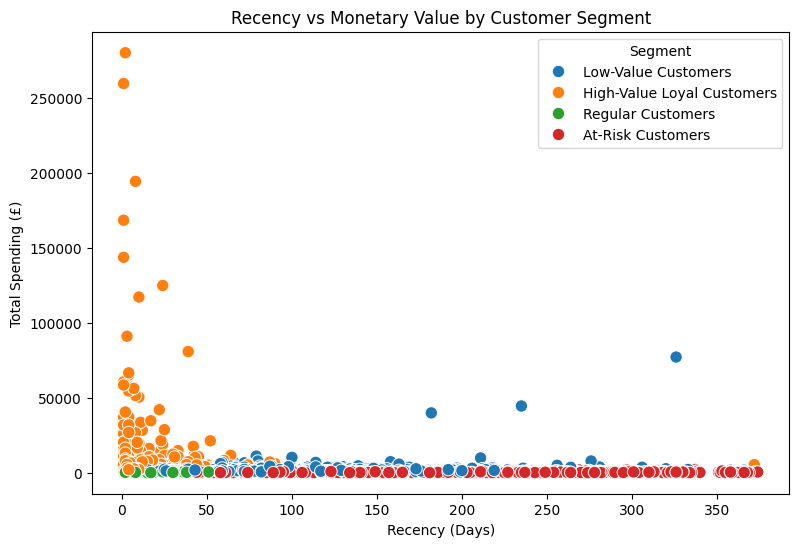

In [77]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=80
)

plt.title('Recency vs Monetary Value by Customer Segment')
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending (£)')

plt.show()

In [78]:
segment_percentage = (
    rfm['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

,proportion
Segment,
At-Risk Customers,37.39
Low-Value Customers,26.88
Regular Customers,19.29
High-Value Loyal Customers,16.44


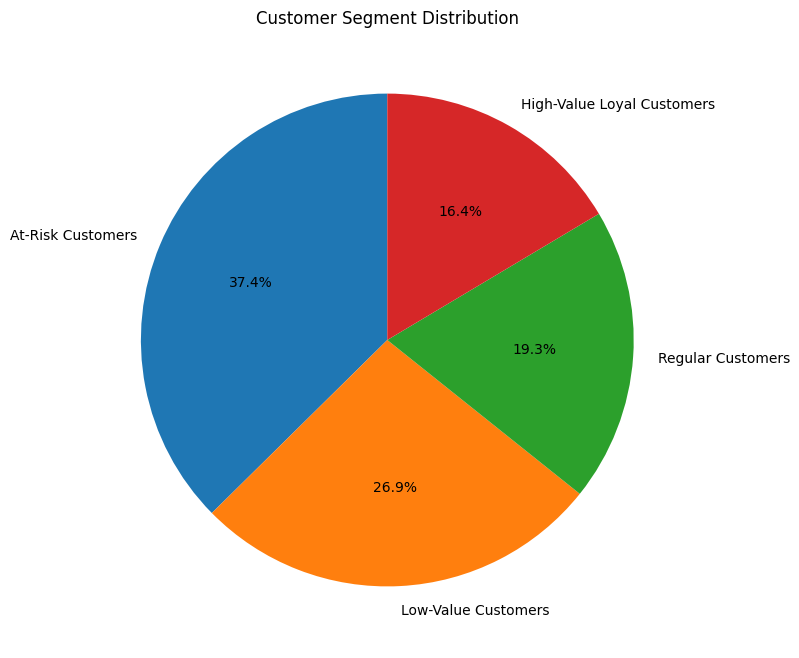

In [79]:
plt.figure(figsize=(8, 8))

plt.pie(
    segment_percentage,
    labels=segment_percentage.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Segment Distribution')

plt.show()